In [71]:
from google.colab import files
import zipfile

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("mnist_data")

print("Extraction complete!")

Saving archive.zip to archive (2).zip
Extraction complete!


In [73]:
import numpy as np
import os

def load_mnist_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = np.frombuffer(
            f.read(16), dtype=np.uint32).view(np.dtype(np.uint32).newbyteorder('>'))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        magic, num = np.frombuffer(
            f.read(8), dtype=np.uint32).view(np.dtype(np.uint32).newbyteorder('>'))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

base_data_path = 'mnist_data'

# Define original paths to the extracted MNIST files within 'mnist_data'
train_images_path_orig = os.path.join(base_data_path, 'train-images-idx3-ubyte')
train_labels_path_orig = os.path.join(base_data_path, 'train-labels-idx1-ubyte')

# Adjust paths if they are directories and the actual file is inside
train_images_path = train_images_path_orig
train_labels_path = train_labels_path_orig

if os.path.isdir(train_images_path_orig):
    train_images_path = os.path.join(train_images_path_orig, os.path.basename(train_images_path_orig))
    print(f"Detected '{train_images_path_orig}' as a directory. Adjusted image path to: {train_images_path}")

if os.path.isdir(train_labels_path_orig):
    train_labels_path = os.path.join(train_labels_path_orig, os.path.basename(train_labels_path_orig))
    print(f"Detected '{train_labels_path_orig}' as a directory. Adjusted label path to: {train_labels_path}")

# Check if files exist and load them
if os.path.exists(train_images_path) and os.path.exists(train_labels_path):
    print(f"Loading images from {train_images_path}...")
    images = load_mnist_images(train_images_path)
    labels = load_mnist_labels(train_labels_path)
    print("Images:", images.shape)
    print("Labels:", labels.shape)
else:
    print(f"MNIST .ubyte files not found at expected paths. Tried original: {train_images_path_orig}, {train_labels_path_orig}. Tried adjusted: {train_images_path}, {train_labels_path}. Current directory contents of '{base_data_path}': {os.listdir(base_data_path) if os.path.exists(base_data_path) else 'Directory does not exist.'}")
    images = np.array([]) # Ensure images is defined as an empty array if not loaded
    labels = np.array([])

Detected 'mnist_data/train-images-idx3-ubyte' as a directory. Adjusted image path to: mnist_data/train-images-idx3-ubyte/train-images-idx3-ubyte
Detected 'mnist_data/train-labels-idx1-ubyte' as a directory. Adjusted label path to: mnist_data/train-labels-idx1-ubyte/train-labels-idx1-ubyte
Loading images from mnist_data/train-images-idx3-ubyte/train-images-idx3-ubyte...
Images: (60000, 28, 28)
Labels: (60000,)


In [74]:
def extract_features(images):
    features = []

    for img in images:
        img = img / 255.0

        mean = np.mean(img)
        std = np.std(img)
        max_val = np.max(img)
        min_val = np.min(img)

        density = np.sum(img > 0.3)

        coords = np.column_stack(np.where(img > 0.3))
        if len(coords) > 0:
            center_y, center_x = coords.mean(axis=0)
        else:
            center_y, center_x = 0, 0

        features.append([
            mean, std, max_val, min_val,
            density, center_x, center_y
        ])

    return np.array(features)

X_features = extract_features(images)
print("Feature shape:", X_features.shape)

Feature shape: (60000, 7)


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

In [76]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

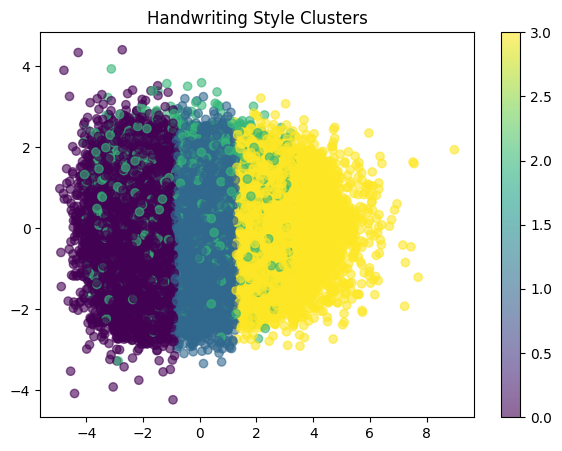

In [77]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, alpha=0.6)
plt.title("Handwriting Style Clusters")
plt.colorbar()
plt.show()

In [78]:
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

y_raw = (
    0.35 * X_scaled[:, 0] +
    0.25 * X_scaled[:, 1] +
    0.15 * X_scaled[:, 4] +
    np.random.normal(0, 0.2, len(X_scaled))
)

y = MinMaxScaler().fit_transform(y_raw.reshape(-1,1)).flatten()

In [79]:
X_final = np.column_stack((X_scaled, clusters))

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score :", r2)
print("RMSE     :", rmse)

R2 Score : 0.9313182113393451
RMSE     : 0.031085477080339437


In [81]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_final, y, cv=5, scoring='r2')
print("CV Mean R2:", cv_scores.mean())

CV Mean R2: 0.9312192283812786


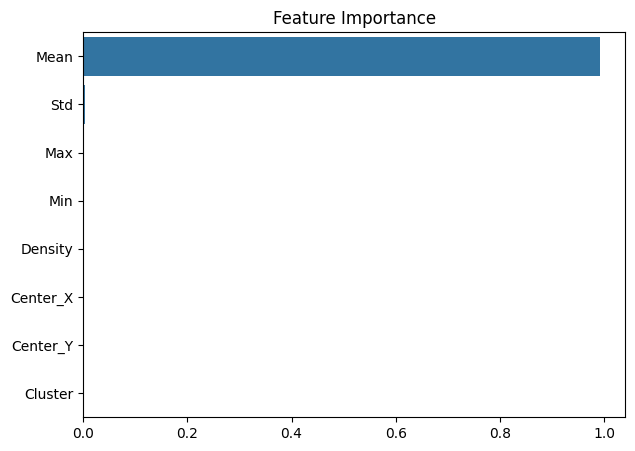

In [82]:
import seaborn as sns

feature_names = [
    "Mean","Std","Max","Min",
    "Density","Center_X","Center_Y","Cluster"
]

plt.figure(figsize=(7,5))
sns.barplot(x=model.feature_importances_, y=feature_names)
plt.title("Feature Importance")
plt.show()

In [83]:
import cv2

def analyze_handwriting(image):
    img = cv2.resize(image, (28,28))
    features = extract_features([img])
    scaled = scaler.transform(features)

    cluster = kmeans.predict(scaled)[0]

    final_input = np.append(scaled[0], cluster).reshape(1, -1)

    prediction = model.predict(final_input)[0]

    print("\n--- ANALYSIS REPORT ---")
    print("Cluster :", cluster)
    print("Extraversion Score :", round(prediction, 3))
    print("Model R2 :", round(r2, 3))

# Test
analyze_handwriting(images[100])


--- ANALYSIS REPORT ---
Cluster : 0
Extraversion Score : 0.268
Model R2 : 0.931
